# SVM Classifier for Non-Linearly Separable Data

In [1]:
# Import usual libraries
import numpy as np
import matplotlib.pyplot as plt

# Make all figures tiny for readability purpose
from matplotlib import rcParams
rcParams['figure.figsize'] = (5,3)

## 1. Let's Create Our "XOR" Dataset

Let's try to classify this kind of non-linearly separable dataset

<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/05-Model-Tuning/non-linear-dataset.png" width=450>

For this purpose, we'll create a 2D dataset using [logical XOR gates](https://en.wikipedia.org/wiki/XOR_gate)

Play with `np.logical_xor` in the cells below to understand how it works:

In [2]:
print(np.logical_xor(True, True))
print(np.logical_xor(True, False))
print(np.logical_xor(False, False))

False
True
False


In [3]:
np.logical_xor([True, True, False], [True, False, False])

array([False,  True, False])

Now let's create our synthetic 2D dataset with the following rule:

$$ y = 
\begin{cases}
    1 & \text{if } (X_1>0 \textbf{ xor } X_2>0) \\
    0 & \text{otherwise}
\end{cases}
$$


In [4]:
# Number of datapoints
n = 500
noise = 0.2

Text(0, 0.5, 'X2')

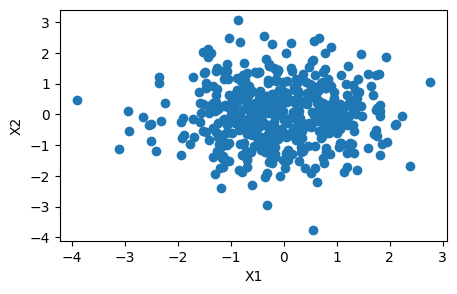

In [5]:
rng = np.random.default_rng(0)
X = rng.standard_normal((n, 2))
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("X1")
plt.ylabel("X2")


In [6]:
print(X.shape)
x1 = X[:, 0]
x2 = X[:, 1]

(500, 2)


In [7]:
# Then, build our binary class y
# where y=1 if and only if (X1 > ε xor X2 > ε)
# epsilon ε not exactly zero to simulate "noise"

epsilon = noise * rng.standard_normal(n)

y_bool = np.logical_xor(
    x1 > epsilon,
    x2 > epsilon
)
y = np.where(y_bool, 1, 0)

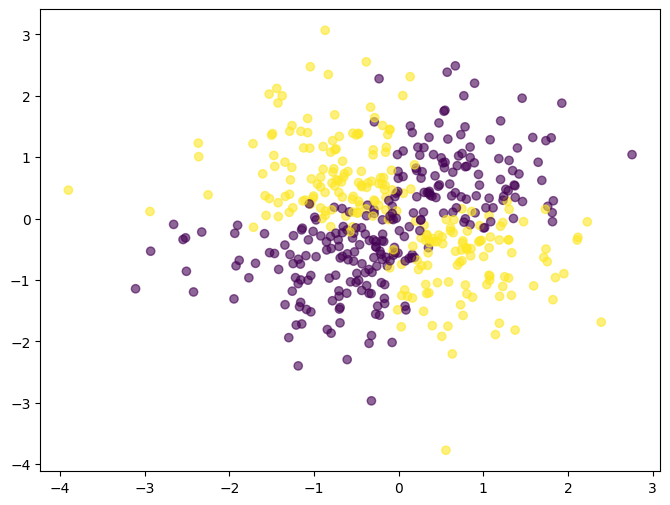

In [8]:
# We have re-created the XOR quadrant!
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.6)
plt.show()

## 2 - Linear SVM

Welcome to the _Support Vector Machine (SVM)_ 🎉

The goal of the linear SVM classifier is to find the best vector **w**

<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/05-Model-Tuning/hyperplane.png" width=500>

- its direction uniquely defines the decision boundary hyperplane
- and minimizes the sum of hinge losses for outliers

👉 **w** contains all the model parameters learned during `.fit()`  
👉 `C` is the **cost** associated with **mis**classification

___
❓ Train a **linear** SVC classifier with `C` = 1 on the entire dataset.

In [9]:
from sklearn.svm import SVC
svm = SVC(kernel='linear', C=1)

# Train the classifier
svm.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


❓ Visualize your model's decision boundaries using the `plot_decision_regions` function provided in `utils/plots.py`

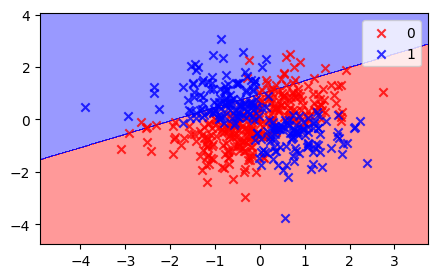

In [10]:
from utils.plots import plot_decision_regions

plot_decision_regions(X, y, classifier=svm)

❓ Record below the accuracy score you "predict" (approximately) for this model

In [ ]:
#linear_svm_score = ?

In [11]:
linear_svm_score = 0.5

❓ Do you think the value of `C` matters in this case?

<details><summary>Answer</summary>
    
☝️ Linear SVM classifiers always separate data points with a straight line, regardless of the cost `c` applied to misclassified data points. We are trying to fit the structurally wrong model type to the dataset.

</details>

❓ Do you think Logistic Regression would perform better? Feel free to try it out.

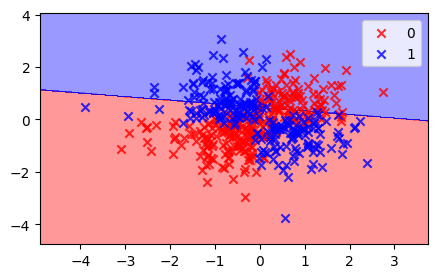

In [12]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X, y)
plot_decision_regions(X, y, classifier=log_reg)


🧪 Test your code

In [13]:
from nbresult import ChallengeResult

result = ChallengeResult('linear_svm',
    linear_svm_score=linear_svm_score)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-svm/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 1 item

test_linear_svm.py::TestLinearSvm::test_score PASSED                     [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/linear_svm.pickle

git commit -m 'Completed linear_svm step'

git push origin master



## 3. Kernel SVM 🔥

❓ In your own words, what is a Kernel - in one sentence?

<details>
    <summary>Possible answer</summary>

It is a measure of "similarity" between points used for classification in SVM models (two points with high similarity are classified in a similar way)
</details>

❓ Name the 4 different kernels below

<details>
    <summary>Possible answer</summary>

- Linear
- Polynomial
- Radial Basis Function (rbf)
- Sigmoid
</details>

## 3.2 Polynomial Kernels

The degree-2 polynomial kernel is as follows:
    $$K(\textbf{a},\textbf{b}) = (\textbf{a}^T\textbf{b} + c )^2$$

By changing the kernel, we changed our notion of _similarity_: instead of measuring how close points are using the dot product ("cosine similarity") for the linear kernel, we now measure similarity based on **whether points lie within a circle relative to each other**.

This is **equivalent** to creating new quadratic features as follows (Kernel Trick):
    $$\phi(x) = \begin{bmatrix} x_1^2 \\ x_1 x_2 \\ x_2 x_1 \\ x_2^2 \\  \sqrt{2c} \ x_1 \\ \sqrt{2c} \ x_2\end{bmatrix}$$

❓ Intuitively speaking, what is the minimum kernel "degree" `d` we need to best fit our XOR dataset?

<details>
    <summary>Answer</summary>

`d=2` should be sufficient because our XOR condition can be computed from the polynomial `x1 * x2`
    
$$    
    class = 
\begin{cases}
    0 & \text{if } x_1 x_2 > 0\\
    1 & \text{otherwise}
\end{cases}
$$
</details>


❓ Train and plot a degree-2 `poly` SVM, keeping `C = 100` large enough to visualize the "maximum margin classifier"

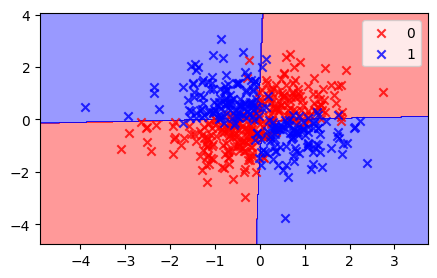

In [18]:
poly_svm = SVC(kernel='poly', degree=2, C=100)
poly_svm.fit(X, y)
plot_decision_regions(X, y, classifier=poly_svm)

❓ Given that you know how this XOR dataset was designed, which adjectives best describe your svm's performance?

In [19]:
a = "is underfitting"
b = "captures all reducible error"
c = "has too high variance"
d = "has only irreducible errors left"

poly_svm_performance = None # [?] # fill the list with the answer(s)
poly_svm_performance = [b, d]


🧪 Test your code

In [20]:
from nbresult import ChallengeResult

result = ChallengeResult('poly_svm',
    poly_svm_performance=poly_svm_performance)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-svm/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 1 item

test_poly_svm.py::TestPolySvm::test_performance PASSED                   [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/poly_svm.pickle

git commit -m 'Completed poly_svm step'

git push origin master



❓ Still not convinced? You can double-check that the polynomial kernel is equivalent to having polynomial features by training the following model:

- First we create polynomial features (feature engineering)
- and then we train a linear SVM.

(Don't worry about the pipeline syntax, we'll see more about pipelines in the next lecture! 🔥)

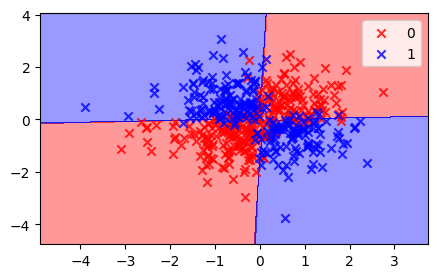

In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# Choose your degree
degree = 2

equivalent_polynomial_model = make_pipeline(
    (PolynomialFeatures(degree=degree)),  # First, create all polynomial combinations of your features
    (SVC(kernel="linear", C=100))  # Then, fit a linear SVM
)
equivalent_polynomial_model.fit(X, y)
plot_decision_regions(X, y, classifier=equivalent_polynomial_model)

☝️ Although mathematically equivalent, this manual feature engineering requires much more computational power than the kernel trick and does not scale with higher dimensionality!

### Moons Dataset

Now let's try with a dataset that is harder to classify!

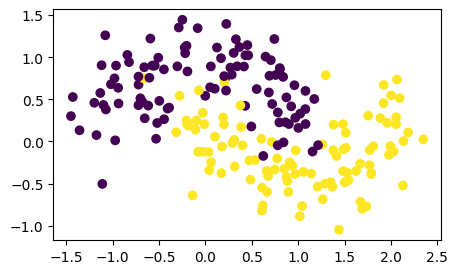

In [22]:
from sklearn.datasets import make_moons

n=200
X,y = make_moons(n_samples=n, noise=0.25, random_state=0)
plt.scatter(X[:,0], X[:,1], c=y);

❓ Try fitting a polynomial SVM kernel to this dataset

Experiment **visually** below by varying `C`, `degree`, and `coef0`.

`coef0` plays the role of $c$ in the formula $K(\textbf{a},\textbf{b}) = (\textbf{a}^T\textbf{b} + c )^d$
- When equal to 0, you only have access to degree-d polynomial features
- The higher it is, the more your model takes lower-degree features into account

In [23]:
from ipywidgets import interact # pip install ipywidgets if you haven't done it already

@interact(C=[1, 10, 1000, 10000, 100000], degree=[1,2,3,4,5,6,7,8,9], coef0=[0,0.5,1,2,5,10,100])
def svc(C, degree, coef0):
    svm = SVC(kernel='poly', C=C, coef0=coef0, degree=degree)
    svm.fit(X, y)
    plot_decision_regions(X, y, classifier=svm)

interactive(children=(Dropdown(description='C', options=(1, 10, 1000, 10000, 100000), value=1), Dropdown(descr…

☝️ The polynomial kernel can fit almost anything as long as the degree is high enough.  

However, keep in mind that very high-degree polynomial kernels will make models prone to overfitting!


## 3.3 RBF - Radial Basis Function Kernel (also known as gaussian)

The RBF Kernel is here! 
The almost indispensable kernel for SVM (and the default in sklearn).   

It proves to be very robust against various problems and is easier to tune than polynomial, because it only requires grid searching the kernel hyperparameter `gamma` $\gamma$, on top of `C`

$K(\textbf{a},\textbf{b}) = \exp[ \left( - \gamma ||\textbf{a}-\textbf{b}||^2\right)$

- The larger the euclidean distance between two points $||\textbf{a}-\textbf{b}||^2$, the closer the kernel function is to zero. This means that two points far apart are more likely to be different.

- `gamma` $\gamma$ reduces the range of influence of each example on others (**myopia**). Stronger $\gamma$ values lead your model to overfit by looking "too closely" at small-scale irregularities

- `C` still controls the **hardness** of the margin. Stronger values lead your model to overfit.

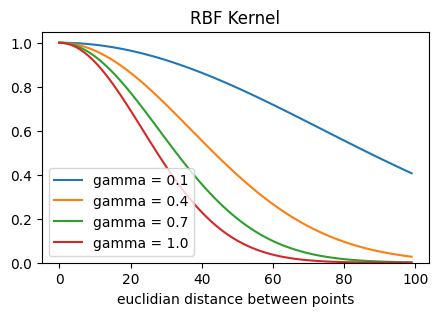

In [24]:
# Let's show below the impact of gamma "myopia" in the Kernel
for gamma in np.linspace(0.1, 1, 4):
    plt.plot(np.exp(-gamma*np.linspace(0, 3, 100)**2),
             label=f'gamma = {gamma}')
plt.ylim(0,)
plt.title('RBF Kernel')
plt.xlabel('euclidian distance between points')
plt.legend();

❓ Train an SVM classifier with the RBF kernel and plot the decision regions

- Start with a very low-variance model (e.g. `gamma=0.01` and `C=0.1`)
- Increase `gamma` until you observe clear overfitting. It should be clearly visible in the plot. 

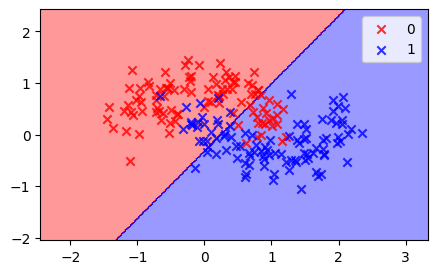

In [25]:
rbf_svm = SVC(kernel='rbf', gamma=0.01, C=0.1)
rbf_svm.fit(X, y)
plot_decision_regions(X, y, classifier=rbf_svm)

❓ Now, use your best estimated value of gamma (e.g. `gamma=1`) and this time increase `C` until overfitting


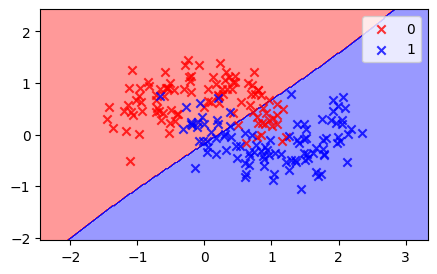

In [26]:
rbf_svm = SVC(kernel='rbf', gamma=0.1, C=0.1)
rbf_svm.fit(X, y)
plot_decision_regions(X, y, classifier=rbf_svm)

☝️ Feel free to build your own interactive plot using `@interact` as above and try to find the best `C` and `gamma` "visually"

In [ ]:
from ipywidgets import interact
import ipywidgets as widgets

@interact(C=[0.1, 1, 10, 100, 1000, 10000], gamma = [0.001, 0.01, 0.1, 1, 10])
def svc(C=1, gamma=1):
    svm = SVC(kernel='rbf', gamma=gamma, C=C)
    svm.fit(X, y)
    plot_decision_regions(X, y, classifier=svm)

interactive(children=(Dropdown(description='C', index=1, options=(0.1, 1, 10, 100, 1000, 10000), value=1), Dro…

❓ Store your best visual estimate values for `C` and `gamma` below (rounded to powers of ten: 0.1, 1, 10, 100 ...)

In [28]:
best_c = 1
best_gamma = 1

🧪 Check your code

In [29]:
from nbresult import ChallengeResult
result = ChallengeResult('rbf_svm',
                         best_c=best_c,
                         best_gamma=best_gamma)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-svm/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 1 item

test_rbf_svm.py::TestRbfSvm::test_hyperparams PASSED                     [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/rbf_svm.pickle

git commit -m 'Completed rbf_svm step'

git push origin master



## 3.4 Sigmoid Kernel

$K(\textbf{a},\textbf{b}) = tanh(\gamma \textbf{a}^T \textbf{b} +r)$

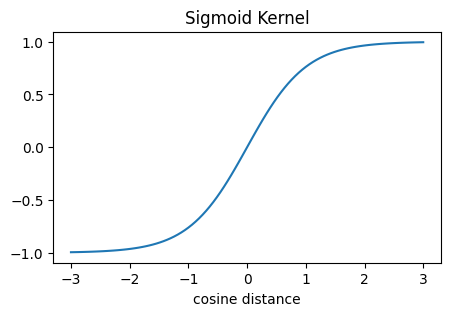

In [30]:
# The "tangent hyperbolic" function resembles sigmoid but can take negative values
x = np.linspace(-3,3,100)
plt.plot(x, np.tanh(x))
plt.xlabel('cosine distance'); plt.title('Sigmoid Kernel');

☝️ The Sigmoid kernel squishes the "cosine similarity" used in the linear kernel into the range [-$\gamma$,+$\gamma$].

❓ Try to **visually** fine-tune your model with the Sigmoid kernel, doing a rough grid search for
- `C=[0.1, 1, 10, 100, 1000, 10000]` 
- `gamma = [0.001, 0.01, 0.1, 1, 10]`  

Using the `@interact` decorator together with the `plot_decision_regions` function

In [ ]:
@interact(C=[0.1, 1, 10, 100, 1000, 10000], gamma = [0.001, 0.01, 0.1, 1, 10], coef0=0.)
def svc(C=1000, gamma=0.1, coef0=0):
    svm = SVC(kernel='sigmoid', gamma=gamma, C=C, coef0=coef0)
    svm.fit(X, y)
    plot_decision_regions(X, y, classifier=svm)

interactive(children=(Dropdown(description='C', index=4, options=(0.1, 1, 10, 100, 1000, 10000), value=1000), …

☝️ Not easy to make it work visually, is it? Time for automated GridSearch!

## 4. Find the Best Kernel with Grid Search

❓ Run `RandomizedSearchCV` simultaneously for the best `kernel` and the best kernel hyperparameters (warning: scikit-learn has trouble grid searching polynomial kernels at the same time as others)
 
Use your visual intuitions from above to define sensible value ranges to try

In [32]:
from sklearn.model_selection import RandomizedSearchCV
from scipy import stats

model = SVC()

search_space = {
    'kernel': ['sigmoid', 'rbf'],
    'C': [0.1, 1, 5, 10, 50, 100, 1000],
    'gamma': [0.1, 0.5, 1, 2, 3, 5, 10],
    'coef0': [0, 0.1, 1],
}

rsearch = RandomizedSearchCV(
    model, search_space,
    n_jobs=-1, scoring='accuracy', cv=3, n_iter=1000, verbose=0
    )

rsearch.fit(X, y)

/Users/yaren/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 180 is smaller than n_iter=1000. Running 180 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.01, 0.1, ...], 'coef0': [0, 0.1, ...], 'gamma': [0, 0.1, ...], 'kernel': ['sigmoid', 'rbf']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",1000
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if Non

❓ Plot the decision boundaries of your best model

In [ ]:
print(rsearch.best_params_)

{'kernel': 'rbf', 'gamma': 1, 'coef0': 0, 'C': 1}


❓ Evaluate its accuracy with 5-fold cross-validation and store your average result as `best_svm_cv_accuracy`

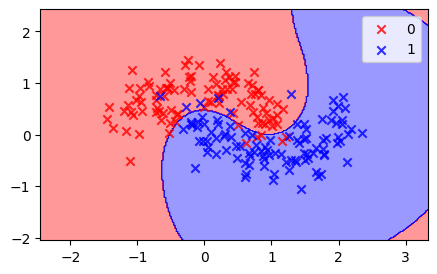

In [40]:
best_svm = rsearch.best_estimator_.fit(X, y)
plot_decision_regions(X, y, classifier=best_svm)

In [41]:
from sklearn.model_selection import cross_val_score
best_svm_cv_accuracy = cross_val_score(best_svm, X, y, cv=5).mean()
best_svm_cv_accuracy

0.9349999999999999

🧪 Test your code

In [42]:
from nbresult import ChallengeResult

result = ChallengeResult('sigmoid_svm',
    best_svm_cv_accuracy=best_svm_cv_accuracy)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-svm/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 1 item

test_sigmoid_svm.py::TestSigmoidSvm::test_accuracy PASSED                [100%]

============================== 1 passed in 0.09s ===============================


💯 You can commit your code:

git add tests/sigmoid_svm.pickle

git commit -m 'Completed sigmoid_svm step'

git push origin master



## 5. Generalization

❓ Select your `best_svm` model to put into "production" in a cloud application. Fit it on the half-moon dataset.

In [73]:
best_svm = SVC(kernel='rbf', C=10, gamma=3).fit(X, y)

A few days later, the model received new data points it had never seen before and made predictions (our "test set")

In [74]:
# Generate a half-moon test_set of size n_test
n_test = 100
X_test, y_test = make_moons(n_samples=n, noise=0.2, random_state=1)

X_full = np.vstack((X, X_test))
y_full = np.append(y, values = y_test)
test_idx = np.arange(n,n+n_test)

❓ Visualize its performance by calling `plot_decision_regions` with `test_idx` as an optional argument.  
Count how many misclassified test examples you get!

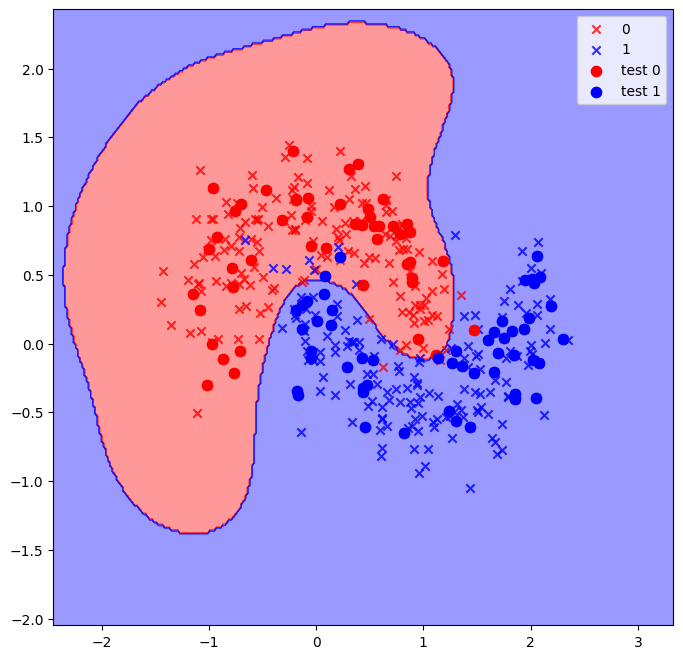

In [75]:
plt.figure(figsize=(8,8))
plot_decision_regions(X_full, y_full, test_idx = test_idx, classifier = best_svm)
plt.legend();

In [76]:
number_misclassified_test = (best_svm.predict(X_test) != y_test).sum()

In [77]:
from nbresult import ChallengeResult

result = ChallengeResult('generalization',
    number_misclassified_test=number_misclassified_test)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-svm/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 1 item

test_generalization.py::TestGeneralization::test_number_misclassified PASSED [100%]

============================== 1 passed in 0.10s ===============================


💯 You can commit your code:

git add tests/generalization.pickle

git commit -m 'Completed generalization step'

git push origin master



## 6. kNN vs. SVM ?

Such a non-linear problem could also be well fitted by a KNN classifier.
Try to find the best K visually and compare its behavior with SVM.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
import ipywidgets as widgets ## add this import

@interact(k=widgets.IntSlider(min=1,max=15,step=1))
def knn(k):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)
    plot_decision_regions(X, y, classifier=knn)

interactive(children=(IntSlider(value=1, description='k', max=15, min=1), Output()), _dom_classes=('widget-int…